In [1]:
# Import pandas library for data analysis
import pandas as pd

# Read the sales dataset into a DataFrame
df = pd.read_csv("../Dataset/superstore_sales.csv")

# Display the first five rows to verify the data loaded correctly
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
# Check the number of missing values in each column
df.isnull().sum()

# Check if any rows are duplicated
df.duplicated().sum()

np.int64(0)

In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# Remove the Postal Code column because it has missing values and is not required for analysis
df.drop('Postal Code', axis=1, inplace=True)

# Display the first five rows to verify the column was removed
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
# Display all column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales'],
      dtype='str')

In [7]:
# Check the number of rows and columns after removing Postal Code
df.shape

(9800, 17)

In [8]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [9]:
df['Order Date'].head(10)

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: Order Date, dtype: str

In [10]:
# Convert Order Date from text to datetime (Day/Month/Year format)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Convert Ship Date from text to datetime (Day/Month/Year format)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [11]:
# Check the updated data types
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object

In [12]:
# Calculate the total sales
total_sales = df['Sales'].sum()

# Display the total sales
print("Total Sales:", total_sales)

Total Sales: 2261536.7827


In [13]:
# Calculate the average sales per order
average_sales = df['Sales'].mean()

# Display the average sales
print("Average Sales:", average_sales)

Average Sales: 230.76905945918367


In [14]:
df['Sales'].mean()

np.float64(230.76905945918367)

In [15]:
print("Average Sales: {:.2f}".format(average_sales))

Average Sales: 230.77


In [16]:
# Group the data by Region and calculate total sales for each region
region_sales = df.groupby('Region')['Sales'].sum()

# Display total sales by region
print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


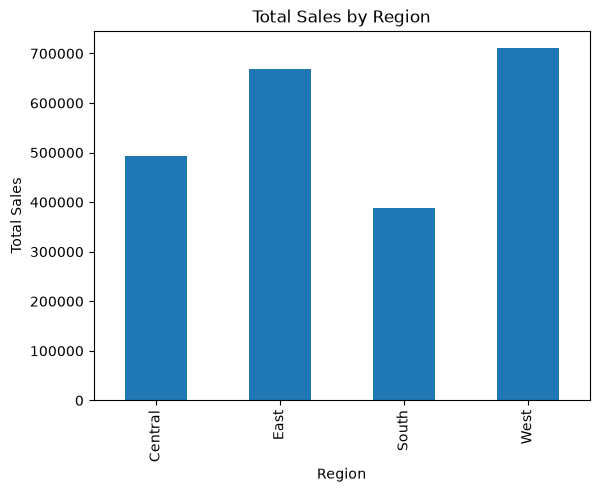

In [17]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a bar chart of total sales by region
region_sales.plot(kind='bar')

# Add chart title and axis labels
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [18]:
# Group the data by Category and calculate total sales
category_sales = df.groupby('Category')['Sales'].sum()

# Display total sales by category
print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


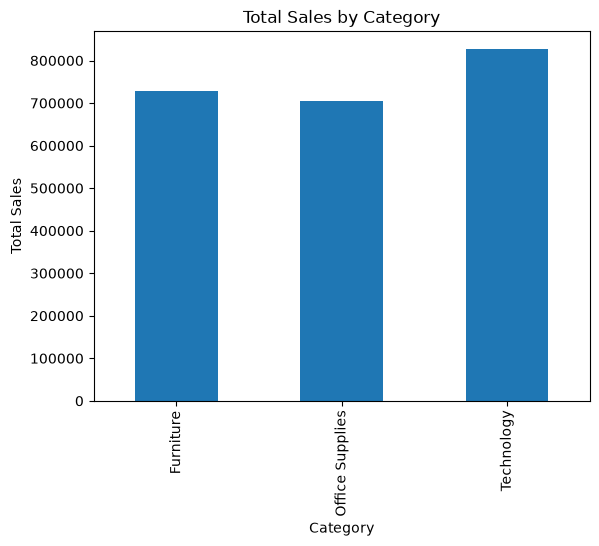

In [19]:
# Create a bar chart of total sales by category
category_sales.plot(kind='bar')

# Add chart title and axis labels
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [20]:
# Create a Month-Year column from Order Date
df['Month-Year'] = df['Order Date'].dt.to_period('M')

In [21]:
# Create a Month-Year column from Order Date
df['Month-Year'] = df['Order Date'].dt.to_period('M')

# Display the first five rows
df[['Order Date', 'Month-Year']].head()

,Order Date,Month-Year
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


In [22]:
# Group the data by Month-Year and calculate total monthly sales
monthly_sales = df.groupby('Month-Year')['Sales'].sum()

# Display the monthly sales
print(monthly_sales.head())

Month-Year
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64


In [23]:
df.groupby('Region')['Sales'].sum()

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

In [24]:
df['Month-Year'] = df['Order Date'].dt.to_period('M')

In [25]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

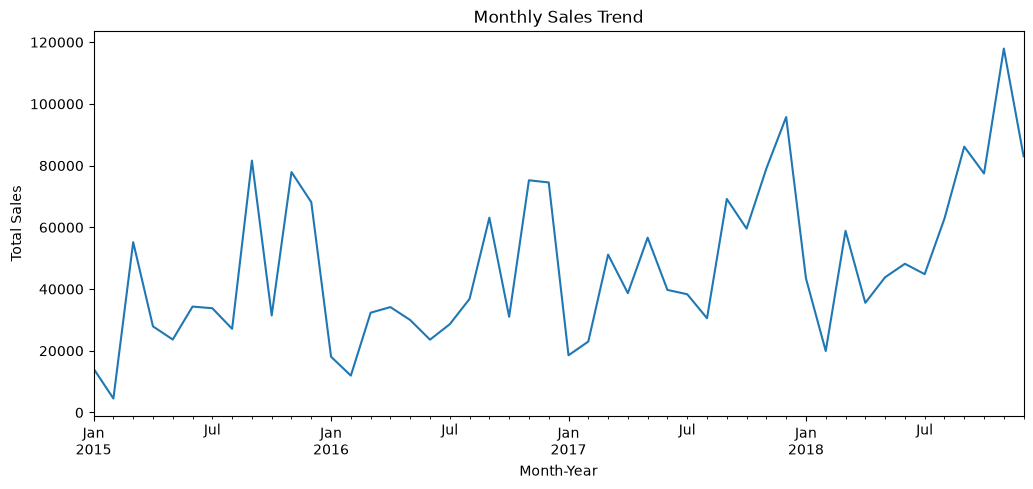

In [26]:
# Create a line chart of monthly sales
monthly_sales.plot(figsize=(12,5))

# Add chart title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [27]:
# Group the data by Customer Segment and calculate total sales
segment_sales = df.groupby('Segment')['Sales'].sum()

# Display total sales for each customer segment
print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


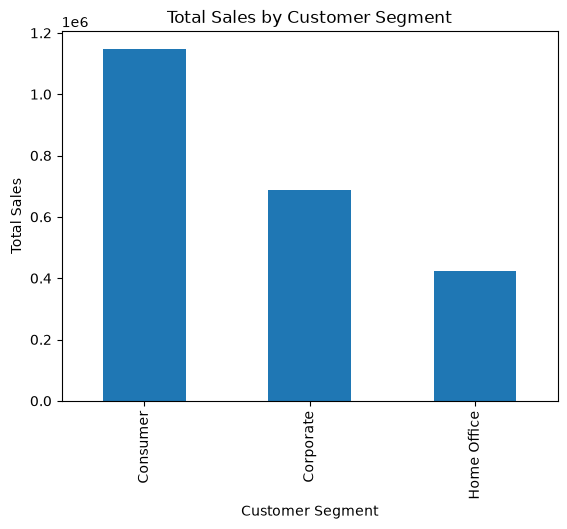

In [28]:
# Create a bar chart of total sales by customer segment
segment_sales.plot(kind='bar')

# Add chart title and axis labels
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [31]:
# Group the data by State and calculate total sales
state_sales = df.groupby('State')['Sales'].sum()

# Sort states by total sales in descending order
state_sales = state_sales.sort_values(ascending=False)

# Display the top 10 states
print(state_sales.head(10))

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


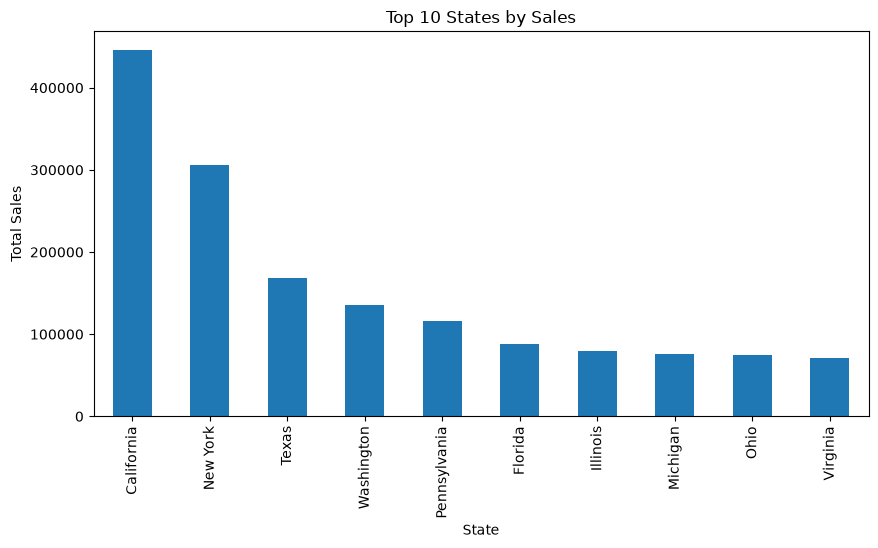

In [33]:
# Create a bar chart of the top 10 states by sales
state_sales.head(10).plot(kind='bar', figsize=(10,5))

# Add chart title and axis labels
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [34]:
# Group the data by Ship Mode and calculate total sales
shipmode_sales = df.groupby('Ship Mode')['Sales'].sum()

# Sort ship modes from highest sales to lowest sales
shipmode_sales = shipmode_sales.sort_values(ascending=False)

# Display total sales by ship mode
print(shipmode_sales)

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


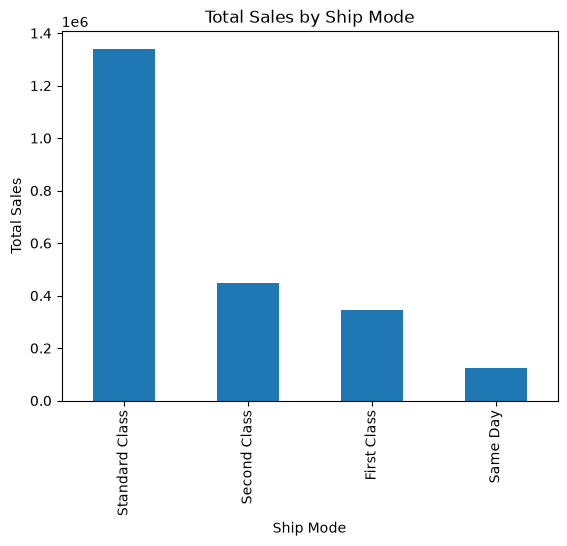

In [35]:
# Create a bar chart of total sales by ship mode
shipmode_sales.plot(kind='bar')

# Add chart title and axis labels
plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [36]:
# Group the data by Ship Mode and calculate total sales
shipmode_sales = df.groupby('Ship Mode')['Sales'].sum()

# Sort ship modes from highest sales to lowest sales
shipmode_sales = shipmode_sales.sort_values(ascending=False)

# Display total sales by ship mode
print(shipmode_sales)

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


In [38]:
# Group the data by Sub-Category and calculate total sales
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum()

# Sort sub-categories from highest sales to lowest sales
subcategory_sales = subcategory_sales.sort_values(ascending=False)

# Display the top 10 sub-categories
print(subcategory_sales.head(10))

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64


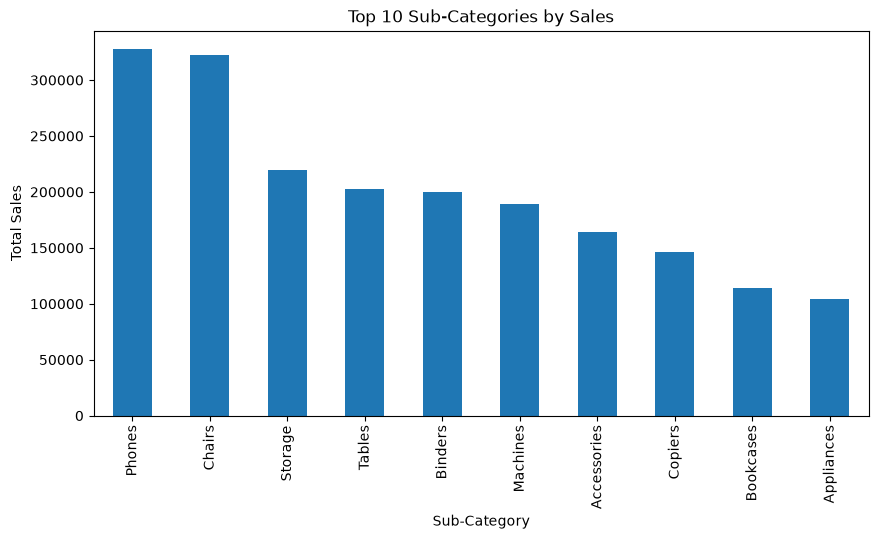

In [39]:
# Create a bar chart of the top 10 sub-categories by sales
subcategory_sales.head(10).plot(kind='bar', figsize=(10,5))

# Add chart title and axis labels
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')

# Display the chart
plt.show()

In [40]:
# Save the cleaned dataset for Power BI
df.to_csv('Cleaned_Sales_Data.csv', index=False)